# Principal component analysis

it is the process where original correlated data is converted to uncorrelated data , so model avoid while predicting 

In [5]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [6]:
df =  pd.read_csv('sample_dataset.csv')

In [7]:
x = df.iloc[:, 0:10].dropna()
x

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
8,13.000,21.82,87.50,519.8,0.12730,0.19320,0.185900,0.093530,0.2350,0.07389
18,19.810,22.15,130.00,1260.0,0.09831,0.10270,0.147900,0.094980,0.1582,0.05395
20,13.080,15.71,85.63,520.0,0.10750,0.12700,0.045680,0.031100,0.1967,0.06811
21,9.504,12.44,60.34,273.9,0.10240,0.06492,0.029560,0.020760,0.1815,0.06905
39,13.480,20.82,88.40,559.2,0.10160,0.12550,0.106300,0.054390,0.1720,0.06419
43,13.280,20.28,87.32,545.2,0.10410,0.14360,0.098470,0.061580,0.1974,0.06782
58,13.050,19.31,82.61,527.2,0.08060,0.03789,0.000692,0.004167,0.1819,0.05501
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.059880,0.021800,0.2341,0.06963
64,12.680,23.84,82.69,499.0,0.11220,0.12620,0.112800,0.068730,0.1905,0.06590
73,13.800,15.79,90.43,584.1,0.10070,0.12800,0.077890,0.050690,0.1662,0.06566


In [8]:
x.shape

(52, 10)

In [9]:
pca =  PCA()
x_pca_all = pca.fit_transform(x)
np.corrcoef(x_pca_all, rowvar= False)

array([[ 1.00000000e+00, -3.41198167e-17,  1.09373853e-16,
         1.32137269e-16, -3.58725671e-17,  4.50079515e-17,
        -1.33375068e-17,  7.83204864e-17,  8.74042763e-17,
         6.73034033e-17],
       [-3.41198167e-17,  1.00000000e+00,  1.31786588e-16,
        -2.04175281e-16, -8.63080250e-17, -1.57710663e-17,
         9.76705599e-17, -3.02772696e-17,  2.94031407e-19,
        -2.89680993e-17],
       [ 1.09373853e-16,  1.31786588e-16,  1.00000000e+00,
         4.90609455e-16,  4.35325834e-17, -3.06899500e-18,
        -4.08405653e-18,  4.63757650e-17,  8.48601464e-18,
         1.06466481e-17],
       [ 1.32137269e-16, -2.04175281e-16,  4.90609455e-16,
         1.00000000e+00,  8.45967244e-17, -2.49395223e-17,
         7.80629237e-17, -6.35057443e-17, -7.02946726e-18,
        -2.84946361e-17],
       [-3.58725671e-17, -8.63080250e-17,  4.35325834e-17,
         8.45967244e-17,  1.00000000e+00,  1.91699601e-17,
         1.53963102e-17, -1.02403957e-16,  5.09330671e-17,
         9.

In [10]:
x_pca_all.shape

(52, 10)

# Dimentionality reduction

In [11]:
pcaa =  PCA(n_components = 5)
x_pcaa_5 = pcaa.fit_transform(x)
x_pcaa_5.shape
np.corrcoef(x_pcaa_5, rowvar= False)

array([[ 1.00000000e+00, -5.05865417e-17,  7.81056358e-17,
         6.32820808e-17, -3.64035721e-17],
       [-5.05865417e-17,  1.00000000e+00,  8.88478154e-17,
        -2.41871340e-16, -9.66240347e-17],
       [ 7.81056358e-17,  8.88478154e-17,  1.00000000e+00,
         3.85304960e-16,  4.97291797e-17],
       [ 6.32820808e-17, -2.41871340e-16,  3.85304960e-16,
         1.00000000e+00,  6.60774877e-17],
       [-3.64035721e-17, -9.66240347e-17,  4.97291797e-17,
         6.60774877e-17,  1.00000000e+00]])

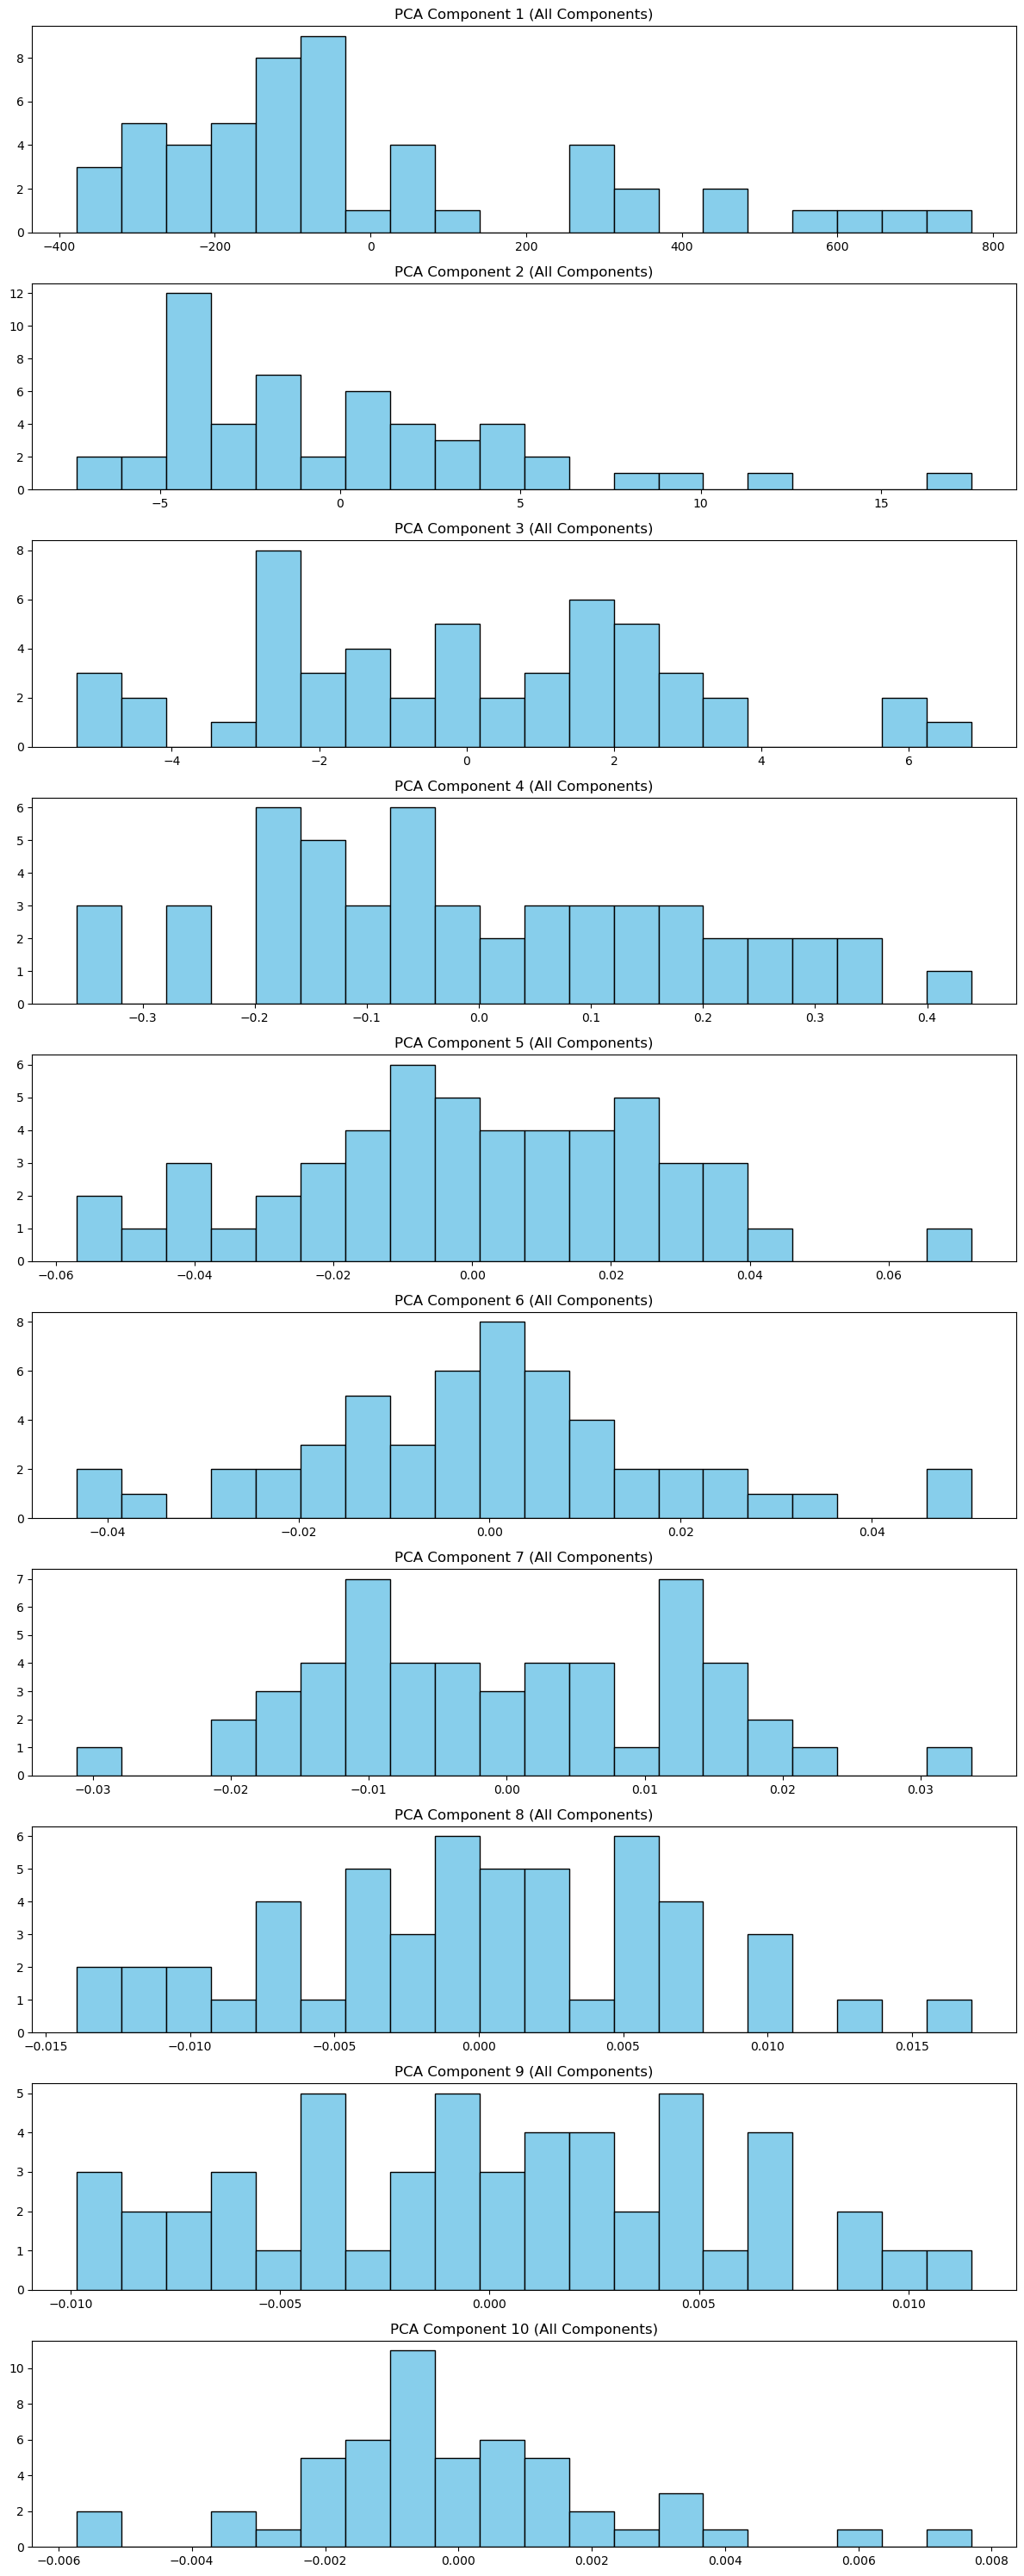

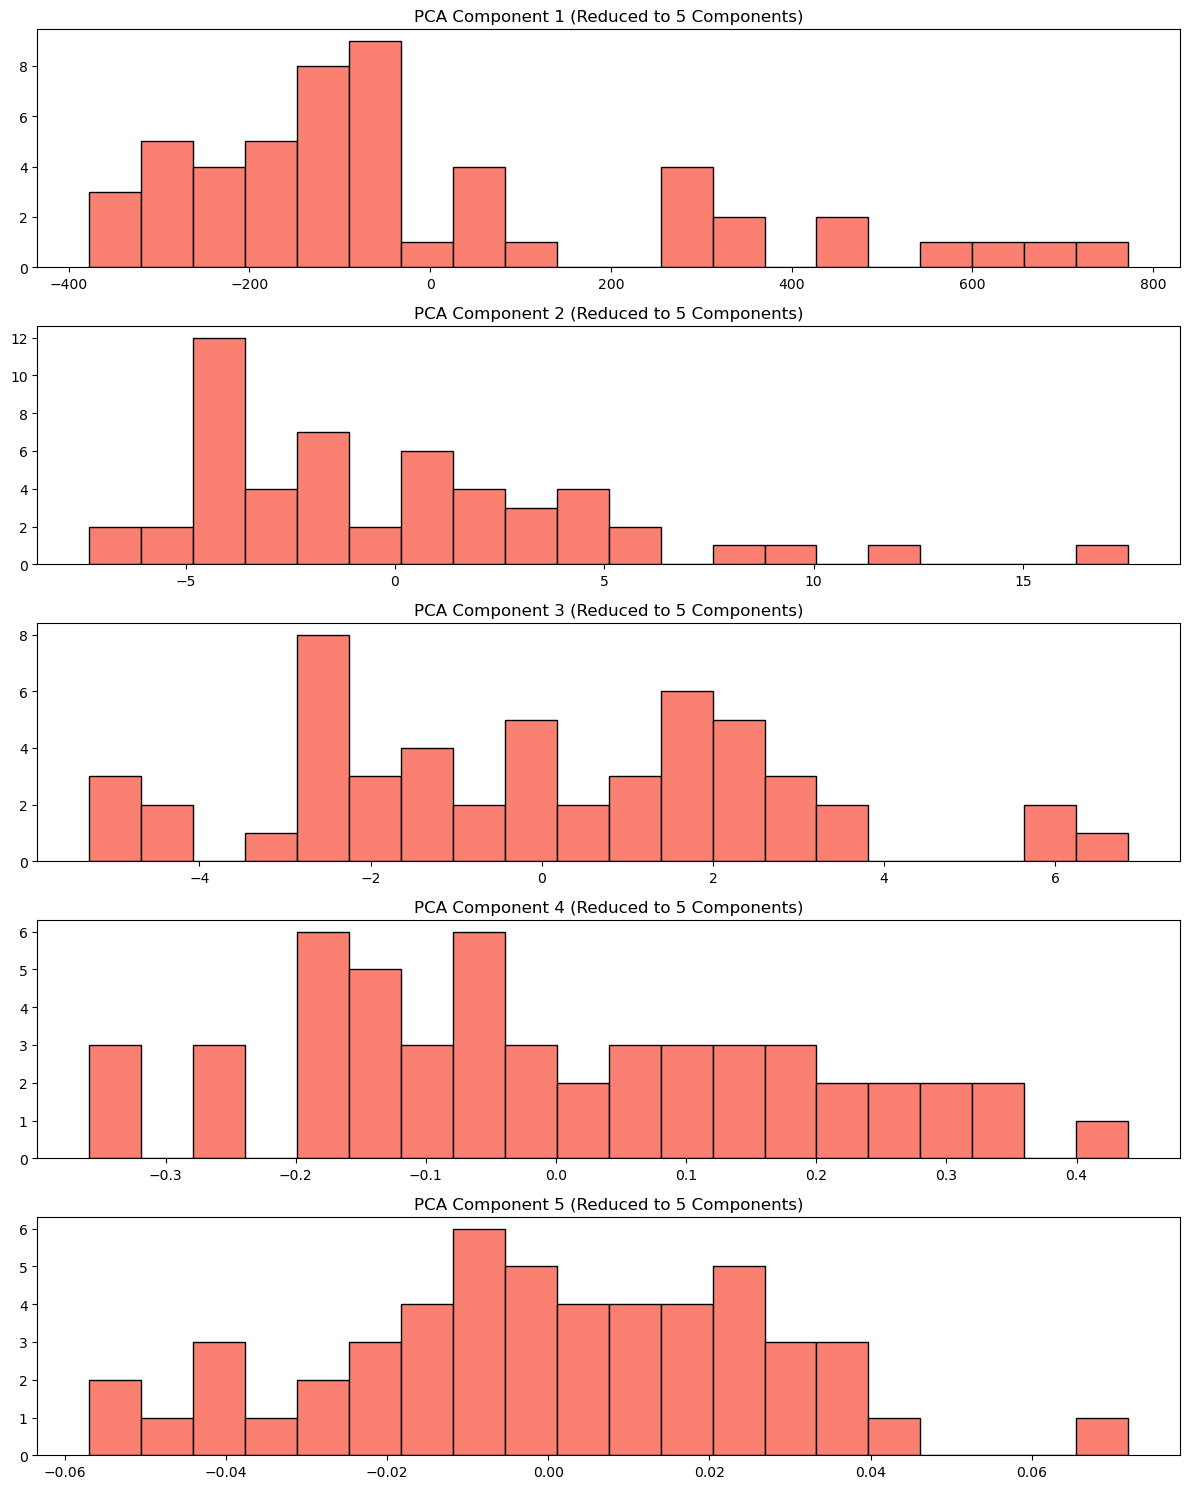

In [15]:

fig, axes = plt.subplots(len(x.columns), 1, figsize=(12, 3 * len(x.columns)))
for i in range(len(x.columns)):
    axes[i].hist(x_pca_all[:, i], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(f'PCA Component {i+1} (All Components)')
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(5, 1, figsize=(12, 15))
for i in range(5):
    axes[i].hist(x_pcaa_5[:, i], bins=20, color='salmon', edgecolor='black')
    axes[i].set_title(f'PCA Component {i+1} (Reduced to 5 Components)')
plt.tight_layout()
plt.show()


In [ ]:
np.cumsum(pca.explained_variance_ratio_)


array([0.99958762, 0.99989938, 0.99999951, 0.99999998, 0.99999999,
       1.        , 1.        , 1.        , 1.        , 1.        ])

In [ ]:

pca_var_filter = PCA(n_components=0.95)
x_pca_filtered = pca_var_filter.fit_transform(x)

print("New shape after variance filter:", x_pca_filtered.shape)
print("Explained variance per component:", pca_var_filter.explained_variance_ratio_)
print("Cumulative explained variance:", np.cumsum(pca_var_filter.explained_variance_ratio_))


New shape after variance filter: (52, 1)
Explained variance per component: [0.99958762]
Cumulative explained variance: [0.99958762]


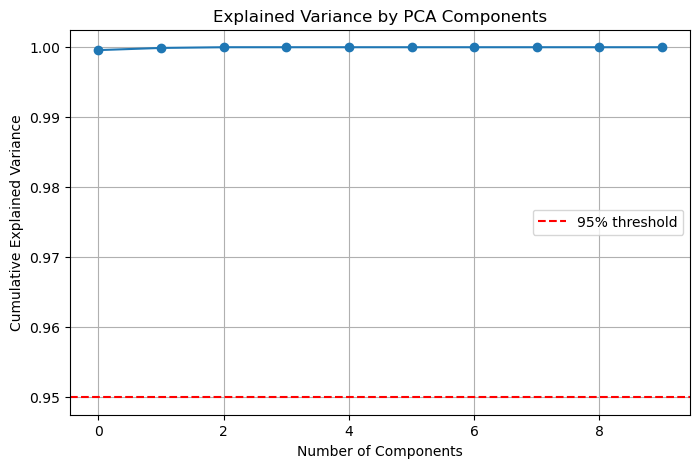

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.legend()
plt.show()



In [16]:
from sklearn.datasets import load_diabetes
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [19]:
x = load_diabetes()['data']
x

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

In [21]:
x_pca = PCA()
x_pca.fit_transform(x)

array([[ 0.02793021, -0.09260136,  0.02802565, ...,  0.03602731,
        -0.00861288, -0.00232845],
       [-0.13468668,  0.06526327,  0.00132849, ..., -0.008963  ,
         0.02402649,  0.00207377],
       [ 0.01294384, -0.07776432,  0.03516224, ...,  0.04010708,
        -0.00120593, -0.00257685],
       ...,
       [-0.00976067, -0.05733918,  0.02360117, ..., -0.02339486,
        -0.00538535,  0.00280039],
       [ 0.03295652,  0.00999473, -0.04132099, ...,  0.0037426 ,
        -0.00605083, -0.00216612],
       [-0.09056122,  0.18910841, -0.0022992 , ...,  0.0563818 ,
         0.03474513, -0.00735156]])

In [22]:
n = len(x_pca.explained_variance_ratio_)

<BarContainer object of 10 artists>

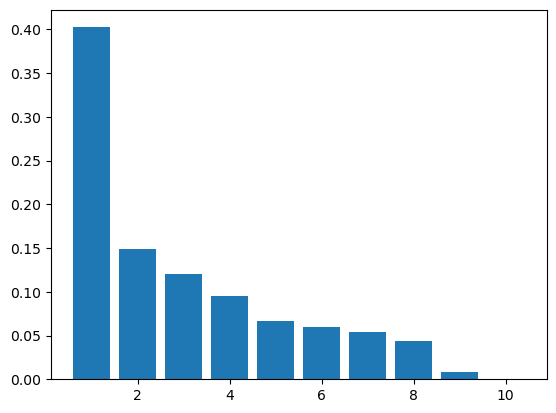

In [24]:
x_ax  = range(1, n+1)
y = x_pca.explained_variance_ratio_
plt.bar(x_ax, y)

In [25]:
x_pca.set_params(n_components = 8)

PCA(n_components=8)

In [ ]:
x_pca.fit_transform(x)


array([[ 0.02793021, -0.09260136,  0.02802565, ..., -0.04809836,
        -0.00855431,  0.03602731],
       [-0.13468668,  0.06526327,  0.00132849, ..., -0.04818423,
         0.0106735 , -0.008963  ],
       [ 0.01294384, -0.07776432,  0.03516224, ..., -0.05292872,
        -0.02199658,  0.04010708],
       ...,
       [-0.00976067, -0.05733918,  0.02360117, ..., -0.00215714,
        -0.03022272, -0.02339486],
       [ 0.03295652,  0.00999473, -0.04132099, ..., -0.02648935,
         0.02595636,  0.0037426 ],
       [-0.09056122,  0.18910841, -0.0022992 , ...,  0.07834195,
         0.01166342,  0.0563818 ]])

<BarContainer object of 8 artists>

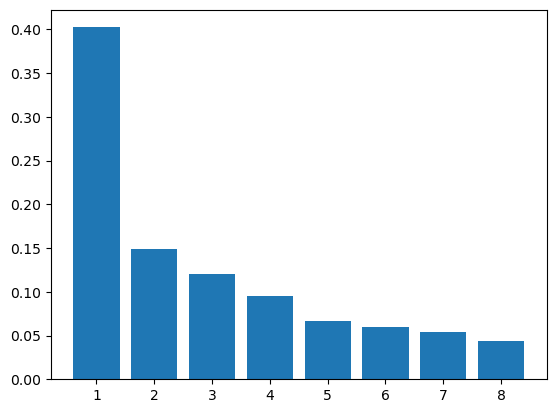

In [29]:
n = len(x_pca.explained_variance_ratio_)
x_ax  = range(1, n+1)
y = x_pca.explained_variance_ratio_
plt.bar(x_ax, y)